Can anomaly detection techniques identify unusual bank transactions that may indicate fraud?

In [45]:
import pandas as pd

df = pd.read_csv("/Users/raynagollapalli/Downloads/bank_transactions_data_2_augmented_clean_2 2.csv")
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [46]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(50000, 15)
Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  object 
 1   AccountID            50000 non-null  object 
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  object 
 4   TransactionType      50000 non-null  object 
 5   Location             50000 non-null  object 
 6   DeviceID             50000 non-null  object 
 7   IP Address           50000 non-null  object 
 8   MerchantID           50000 non-null  object 
 9   Channel              50000

In [47]:
from sklearn.preprocessing import StandardScaler
# Cleaning Data 
df_clean = df.drop(["TransactionID", "AccountID", "IP Address"], axis=1)

df_clean = pd.get_dummies(df_clean)

df_clean = df_clean.fillna(df_clean.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

In [48]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_preds = iso_model.fit_predict(X_scaled)

# Convert (-1 = anomaly, 1 = normal)
df["Anomaly_IF"] = iso_preds

In [49]:
from sklearn.neighbors import LocalOutlierFactor

lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_preds = lof_model.fit_predict(X_scaled)

df["Anomaly_LOF"] = lof_preds

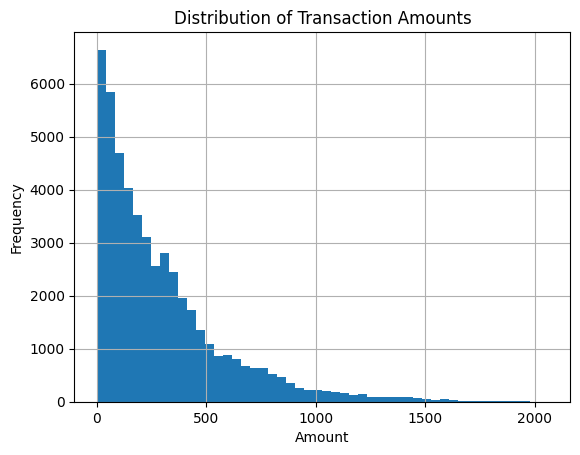

In [50]:
df["TransactionAmount"].hist(bins=50)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

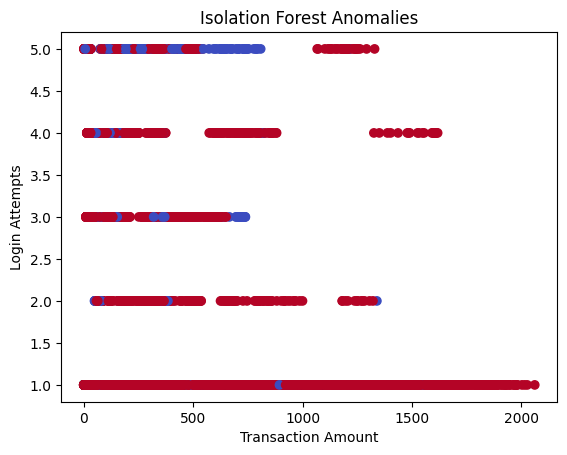

In [51]:
import matplotlib.pyplot as plt

plt.scatter(df["TransactionAmount"], df["LoginAttempts"],
            c=df["Anomaly_IF"], cmap="coolwarm")
plt.xlabel("Transaction Amount")
plt.ylabel("Login Attempts")
plt.title("Isolation Forest Anomalies")
plt.show() 


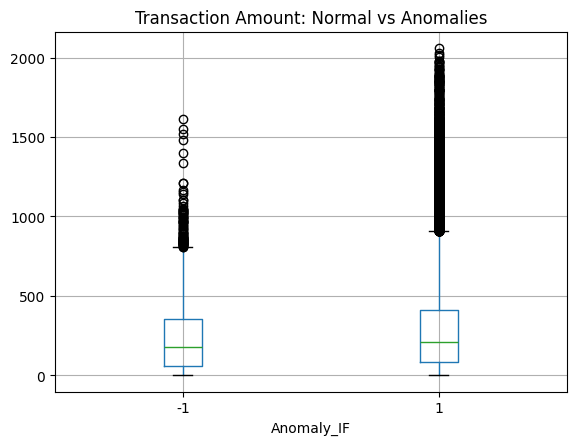

In [52]:
df.boxplot(column="TransactionAmount", by="Anomaly_IF")
plt.title("Transaction Amount: Normal vs Anomalies")
plt.suptitle("")
plt.show()

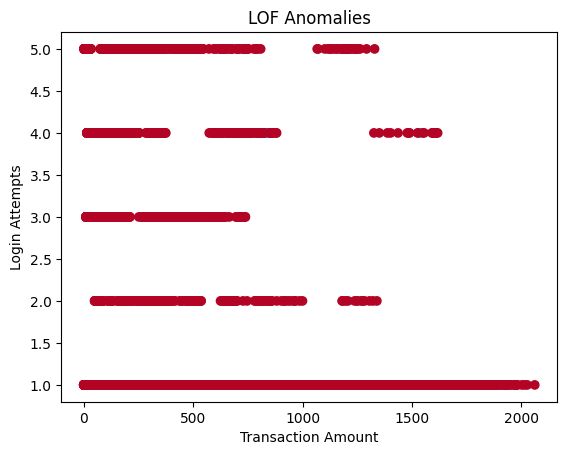

In [53]:
plt.scatter(df["TransactionAmount"], df["LoginAttempts"],
            c=df["Anomaly_LOF"], cmap="coolwarm")
plt.xlabel("Transaction Amount")
plt.ylabel("Login Attempts")
plt.title("LOF Anomalies")
plt.show()

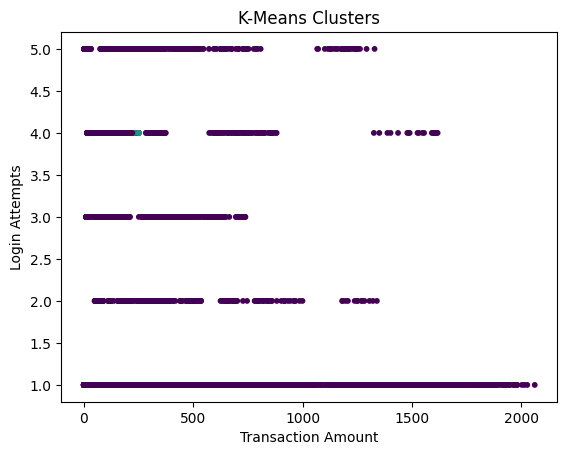

In [54]:
from sklearn.cluster import KMeans

# compute k-means clusters on the scaled features and add to df
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

plt.scatter(df["TransactionAmount"], df["LoginAttempts"],
            c=df["Cluster"], cmap="viridis", s=10)
plt.xlabel("Transaction Amount")
plt.ylabel("Login Attempts")
plt.title("K-Means Clusters")
plt.show()

In [55]:
anomalies = df[df["Anomaly_IF"] == -1]
print(anomalies.head())
print("Number of anomalies:", len(anomalies))

   TransactionID AccountID  TransactionAmount   TransactionDate  \
1       TX000002   AC00455             376.24   6/27/2023 16:44   
14      TX000015   AC00085             166.99   2/13/2023 16:53   
25      TX000026   AC00041               7.49  10/20/2023 17:53   
44      TX000045   AC00011             304.31   7/26/2023 16:52   
46      TX000047   AC00282             164.49  12/13/2023 16:01   

   TransactionType    Location DeviceID      IP Address MerchantID Channel  \
1            Debit     Houston  D000051     13.149.61.4       M052     ATM   
14           Debit  Louisville  D000309  188.124.181.12       M017  Online   
25          Credit     Houston  D000671  81.248.235.147       M043  Online   
44           Debit  Louisville  D000685  77.208.193.198       M005  Branch   
46           Debit   Baltimore  D000103  113.115.81.178       M070  Branch   

    CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
1            68             Doctor                  14

In [56]:
print("Isolation Forest anomalies:", sum(df["Anomaly_IF"] == -1))
print("LOF anomalies:", sum(df["Anomaly_LOF"] == -1))

Isolation Forest anomalies: 2500
LOF anomalies: 2500
